# Harvard's Endowment — Group Case

**FINM Portfolio and Risk Management**

Case link: [Harvard's Endowment](https://markhendricks.github.io/finm-portfolio/case_studies/Harvard%27s%20Endowment.html)

*we can probably delete this author section thing right?*

| Section | Author |
|---|---|
| 2.1 Summary Statistics, 2.2 Descriptive Analysis | *Brendon* |
| 2.3 The MV Frontier, 2.4 TIPS | *Daniil* |
| 3. Allocations | *Vincent and Ansh* |

# 2. Mean-Variance Optimization

## Setup

* **Data:** `data/multi_asset_etf_data.xlsx`, monthly returns of 11 asset-class ETFs plus SHV (short-term T-bill fund).
* **Excess returns:** SHV is the risk-free asset, so every other column is in excess of SHV. We load the `excess returns` sheet and check it against `total returns` − SHV.
* **Adjustment:** QAI is dropped, which leaves **10 assets**.
* **Nominal** returns, with no inflation adjustment.
* **Format:** statistics are annualized (mean × 12, volatility × $\sqrt{12}$, Sharpe × $\sqrt{12}$). The raw time series is never scaled.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:,.4f}'.format
plt.rcParams['figure.figsize'] = (10, 5)

FREQ = 12                                   # monthly data
DATA_PATH = 'data/multi_asset_etf_data.xlsx'

In [3]:
info       = pd.read_excel(DATA_PATH, sheet_name='descriptions').set_index('ticker')
total_rets = pd.read_excel(DATA_PATH, sheet_name='total returns', index_col=0, parse_dates=True)
rets       = pd.read_excel(DATA_PATH, sheet_name='excess returns', index_col=0, parse_dates=True)

# Sanity check: provided excess returns == total returns minus SHV
recomputed = total_rets.drop(columns='SHV').sub(total_rets['SHV'], axis=0)
assert np.allclose(recomputed[rets.columns], rets), 'excess returns sheet inconsistent'

# Adjustment: drop QAI and analyze the remaining 10 assets
rets = rets.drop(columns='QAI')

print(f'Sample: {rets.index[0]:%Y-%m} to {rets.index[-1]:%Y-%m}  ({len(rets)} monthly obs, {rets.shape[1]} assets)')
info.loc[rets.columns, ['shortName']]

Sample: 2011-02 to 2026-07  (186 monthly obs, 10 assets)


,shortName
BWX,State Street SPDR Bloomberg Int
DBC,Invesco DB Commodity Index Trac
EEM,iShares MSCI Emerging Index Fun
EFA,iShares MSCI EAFE ETF
HYG,iShares iBoxx $ High Yield Corp
IEF,iShares 7-10 Year Treasury Bond
IYR,iShares U.S. Real Estate ETF
PSP,Invesco Global Listed Private E
SPY,State Street SPDR S&P 500 ETF T
TIP,iShares TIPS Bond ETF


In [4]:
def performance_summary(df, freq=FREQ):
    # Annualized mean, volatility, and Sharpe ratio of (excess) return series
    out = pd.DataFrame({
        'Mean':       df.mean() * freq,
        'Volatility': df.std() * np.sqrt(freq),
    })
    out['Sharpe'] = out['Mean'] / out['Volatility']
    return out

## 2.1 Summary Statistics

> Calculate and display the mean and volatility of each asset's excess return. Which assets have the best and worst Sharpe ratios?

$$\text{Sharpe ratio}_i = \frac{\tilde{\mu}_i}{\sigma_i}$$

where $\tilde{\mu}_i$ is the mean excess return. All three statistics are annualized.

In [5]:
summary = performance_summary(rets).sort_values('Sharpe', ascending=False)
summary.style.format({'Mean': '{:.2%}', 'Volatility': '{:.2%}', 'Sharpe': '{:.3f}'}) \
       .background_gradient(subset=['Sharpe'], cmap='RdYlGn')

,Mean,Volatility,Sharpe
SPY,12.70%,14.14%,0.898
HYG,3.45%,7.33%,0.471
EFA,6.38%,14.86%,0.429
IYR,7.01%,16.55%,0.423
PSP,7.64%,21.13%,0.362
TIP,1.28%,4.97%,0.257
EEM,4.44%,17.91%,0.248
IEF,0.86%,6.21%,0.138
DBC,1.30%,17.23%,0.075
BWX,-1.72%,8.19%,-0.210


Best Sharpe : SPY (State Street SPDR S&P 500 ETF T)  -> 0.898
Worst Sharpe: BWX (State Street SPDR Bloomberg Int)  -> -0.210


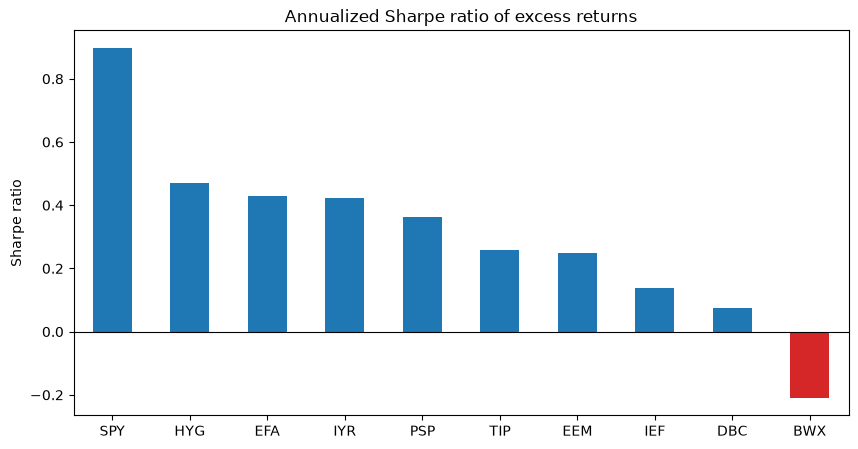

In [6]:
best, worst = summary['Sharpe'].idxmax(), summary['Sharpe'].idxmin()
print(f"Best Sharpe : {best} ({info.loc[best, 'shortName'].strip()})  -> {summary.loc[best, 'Sharpe']:.3f}")
print(f"Worst Sharpe: {worst} ({info.loc[worst, 'shortName'].strip()})  -> {summary.loc[worst, 'Sharpe']:.3f}")

fig, ax = plt.subplots()
summary['Sharpe'].plot.bar(ax=ax, color=np.where(summary['Sharpe'] >= 0, 'tab:blue', 'tab:red'))
ax.axhline(0, color='k', lw=0.8)
ax.set_title('Annualized Sharpe ratio of excess returns')
ax.set_ylabel('Sharpe ratio')
plt.xticks(rotation=0)
plt.show()

**Takeaways (2.1)**

* **Best Sharpe: SPY (U.S. equities), ≈ 0.90.** SPY has the highest mean excess return (≈ 12.7% annualized) with a volatility of only ≈ 14%, which is lower than other equity-like assets such as EEM, IYR, and PSP. Over this sample U.S. equities earned far more per unit of risk than anything else.
* **Worst Sharpe: BWX (foreign government bonds), ≈ −0.21.** It is the only asset with a *negative* mean excess return (≈ −1.7%), so it underperformed T-bills over the sample. Unhedged currency exposure during a period of a strong U.S. dollar explains much of this.
* DBC (commodities) also has a very low Sharpe (≈ 0.08): commodity volatility is equity-like (≈ 17%) but the excess return is close to zero.
* High-yield credit (HYG) ranks second (≈ 0.47) because its volatility is low relative to its mean.
* These are sample estimates. With about 15 years of monthly data, the standard error of an annualized Sharpe ratio is roughly $1/\sqrt{15.5} \approx 0.25$, so the differences between assets in the middle of the ranking are not statistically meaningful.

## 2.2 Descriptive Analysis

> Calculate the correlation matrix of the returns. Which pair has the highest correlation? And the lowest?

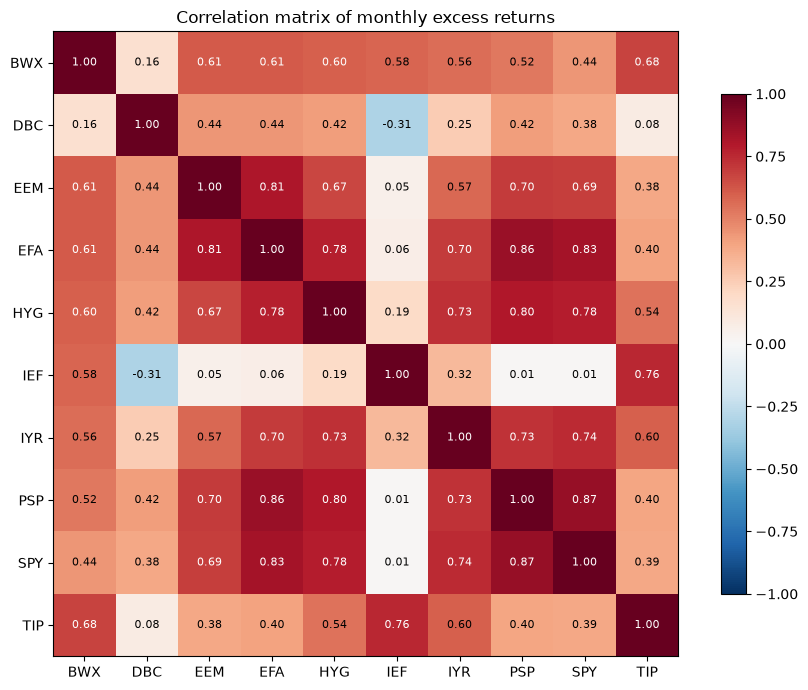

In [7]:
corr = rets.corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns)
ax.set_yticks(range(len(corr)), corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(corr.iloc[i, j]) > 0.6 else 'black')
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Correlation matrix of monthly excess returns')
plt.tight_layout()
plt.show()

In [8]:
# Unique pairs (upper triangle, excluding the diagonal)
mask  = np.triu(np.ones(corr.shape, dtype=bool), k=1)
pairs = corr.where(mask).stack().rename('Correlation').sort_values(ascending=False)
pairs.index.names = ['Asset 1', 'Asset 2']

print('Highest correlation pair:', pairs.index[0],  f'-> {pairs.iloc[0]:.3f}')
print('Lowest  correlation pair:', pairs.index[-1], f'-> {pairs.iloc[-1]:.3f}')

pd.concat({'Top 5': pairs.head(5).reset_index(), 'Bottom 5': pairs.tail(5).reset_index()}, axis=1)

Highest correlation pair: ('PSP', 'SPY') -> 0.872
Lowest  correlation pair: ('DBC', 'IEF') -> -0.309


Top 5                     Bottom 5                    
  Asset 1 Asset 2 Correlation  Asset 1 Asset 2 Correlation
0     PSP     SPY      0.8722      EFA     IEF      0.0629
1     EFA     PSP      0.8616      EEM     IEF      0.0515
2     EFA     SPY      0.8328      IEF     PSP      0.0125
3     EEM     EFA      0.8120      IEF     SPY      0.0113
4     HYG     PSP      0.7983      DBC     IEF     -0.3088

**Takeaways (correlations)**

* **Highest: PSP & SPY (≈ 0.87).** Listed private equity is mostly a portfolio of publicly traded equities, so it moves closely with the U.S. stock market. EFA–PSP (≈ 0.86) and EFA–SPY (≈ 0.83) come next. The equity-like assets (SPY, EFA, EEM, PSP, IYR, HYG) form one highly correlated block, which means they diversify each other less than it looks.
* **Lowest: DBC & IEF (≈ −0.31).** Commodities and intermediate Treasuries move in opposite directions. Inflation and growth surprises push commodity prices up and Treasury prices down, and in risk-off episodes Treasuries rally while commodities sell off.
* IEF is roughly uncorrelated with the equity block (≈ 0.01 with SPY and PSP), which makes Treasuries the main diversifier in this asset set.

> How well have TIPS done in our sample? Have they outperformed domestic bonds? Foreign bonds?

Domestic bonds = **IEF** (7–10y U.S. Treasuries); foreign bonds = **BWX** (international Treasuries).

In [9]:
bonds = ['TIP', 'IEF', 'BWX']

tips_cmp = performance_summary(rets[bonds])
tips_cmp['Cumulative total return'] = (1 + total_rets[bonds]).prod() - 1
tips_cmp['Max drawdown'] = ((1 + total_rets[bonds]).cumprod()
                            .pipe(lambda w: w / w.cummax() - 1).min())
tips_cmp['Corr w/ TIP'] = corr.loc[bonds, 'TIP']

tips_cmp.style.format({'Mean': '{:.2%}', 'Volatility': '{:.2%}', 'Sharpe': '{:.3f}',
                       'Cumulative total return': '{:.1%}', 'Max drawdown': '{:.1%}',
                       'Corr w/ TIP': '{:.2f}'})

,Mean,Volatility,Sharpe,Cumulative total return,Max drawdown,Corr w/ TIP
TIP,1.28%,4.97%,0.257,50.3%,-13.9%,1.00
IEF,0.86%,6.21%,0.138,39.4%,-23.2%,0.76
BWX,-1.72%,8.19%,-0.210,-8.5%,-32.2%,0.68


,Mean,Volatility,Info ratio,t-stat (mean),% months TIP better
TIP - IEF,0.42%,4.08%,0.103,0.40,53.8%
TIP - BWX,2.99%,6.07%,0.493,1.94,56.5%


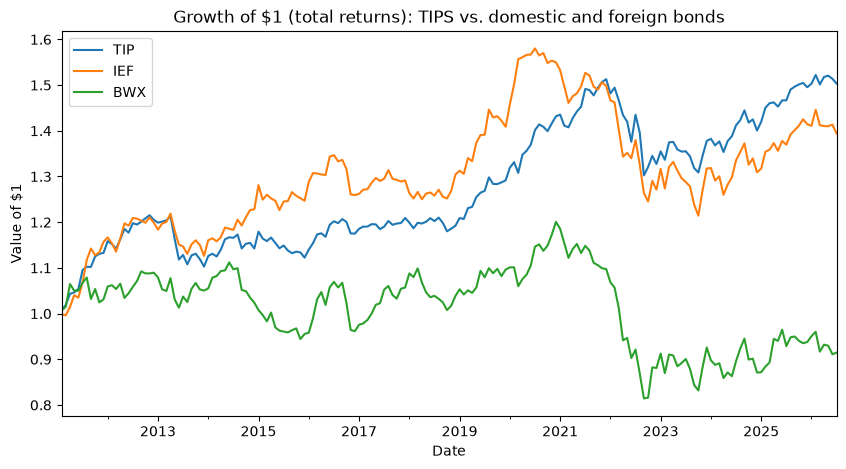

In [10]:
# Outperformance of TIPS: monthly excess-return differences (annualized)
diff = pd.DataFrame({f'TIP - {b}': rets['TIP'] - rets[b] for b in ['IEF', 'BWX']})
diff_stats = performance_summary(diff).rename(columns={'Sharpe': 'Info ratio'})
diff_stats['t-stat (mean)'] = diff.mean() / (diff.std() / np.sqrt(len(diff)))
diff_stats['% months TIP better'] = (diff > 0).mean()
display(diff_stats.style.format({'Mean': '{:.2%}', 'Volatility': '{:.2%}', 'Info ratio': '{:.3f}',
                                 't-stat (mean)': '{:.2f}', '% months TIP better': '{:.1%}'}))

fig, ax = plt.subplots()
(1 + total_rets[bonds]).cumprod().plot(ax=ax)
ax.set_title('Growth of $1 (total returns): TIPS vs. domestic and foreign bonds')
ax.set_ylabel('Value of $1')
plt.show()

**Takeaways (TIPS)**

* **TIPS vs. domestic bonds (IEF):** TIPS earned a slightly higher mean excess return (≈ 1.3% vs. ≈ 0.9%) with *lower* volatility (≈ 5.0% vs. ≈ 6.2%), so the Sharpe ratio is higher (≈ 0.26 vs. ≈ 0.14), and cumulative total return is also higher. TIPS outperformed IEF on a risk-adjusted basis. The margin is small, though, and not statistically significant: the mean of TIP − IEF is only ≈ 0.4% per year (t ≈ 0.4), and TIPS beat IEF in just ≈ 54% of months. Most of the edge comes from the 2021–22 inflation surge, when TIPS outperformed nominal Treasuries by ≈ 9% and ≈ 3%. In most other years they performed about the same or trailed.
* **TIPS vs. foreign bonds (BWX):** TIPS clearly outperformed, by ≈ 3.0% per year (t ≈ 1.9, borderline significant). BWX had a negative excess return, higher volatility, and lost money over the sample in total-return terms.
* **Do TIPS diversify?** TIPS are highly correlated with IEF (≈ 0.76) and BWX (≈ 0.68), so most of their variation is ordinary interest-rate risk. Their correlation with equities is moderate (≈ 0.4). Whether they add value as a separate asset class therefore depends on the part of TIPS returns that is *not* spanned by the other assets. Section 2.4 tests this with the MV frontier.

---
## 2.3 The MV Frontier


In [11]:
# ── 3. The Tangency Portfolio ─────────────────────────────────────────────────

# Sample moments (annualised)
mu    = rets.mean() * FREQ                    # E[r] vector (annualised)
Sigma = rets.cov()  * FREQ                    # Cov matrix  (annualised)

# Tangency weights: w^tan ∝ Σ⁻¹ μ  (long/short, unconstrained)
Sigma_inv  = np.linalg.inv(Sigma.values)
raw        = Sigma_inv @ mu.values            # unnormalised
w_tan      = raw / raw.sum()                  # weights sum to 1

w_tan_s = pd.Series(w_tan, index=rets.columns, name='w_tan')

print('Tangency portfolio weights  (sum =', f'{w_tan_s.sum():.4f})')
w_tan_s.sort_values(ascending=False).to_frame().style \
    .format('{:.4f}') \
    .background_gradient(cmap='RdYlGn')

Tangency portfolio weights  (sum = 1.0000)


,w_tan
IEF,1.3188
SPY,1.2632
HYG,0.2038
EFA,0.1848
DBC,0.0363
EEM,-0.0010
TIP,-0.1920
IYR,-0.2237
PSP,-0.4106
BWX,-1.1797


In [12]:
# ── Weight vs Sharpe-ratio ranking comparison ─────────────────────────────────

comparison = pd.DataFrame({
    'Sharpe':       summary['Sharpe'],          # already computed above
    'w_tan':        w_tan_s,
    'Sharpe_rank':  summary['Sharpe'].rank(ascending=False).astype(int),
    'Weight_rank':  w_tan_s.rank(ascending=False).astype(int),
}).sort_values('Sharpe_rank')

rank_corr = comparison['Sharpe_rank'].corr(comparison['Weight_rank'])
print(f'Rank correlation (Sharpe vs weight): {rank_corr:.3f}')

comparison.style \
    .format({'Sharpe': '{:.3f}', 'w_tan': '{:.4f}',
             'Sharpe_rank': '{:.0f}', 'Weight_rank': '{:.0f}'}) \
    .background_gradient(subset=['Sharpe'],  cmap='RdYlGn') \
    .background_gradient(subset=['w_tan'],   cmap='RdYlGn')

Rank correlation (Sharpe vs weight): 0.382


,Sharpe,w_tan,Sharpe_rank,Weight_rank
SPY,0.898,1.2632,1,2
HYG,0.471,0.2038,2,3
EFA,0.429,0.1848,3,4
IYR,0.423,-0.2237,4,8
PSP,0.362,-0.4106,5,9
TIP,0.257,-0.1920,6,7
EEM,0.248,-0.0010,7,6
IEF,0.138,1.3188,8,1
DBC,0.075,0.0363,9,5
BWX,-0.210,-1.1797,10,10


For SPY, HYG, EFA, TIP, EEM, and BWX the weightings are +- one rank from their relative sharpe ranks. Note though other assets are weighted different from their sharpe_ranks, long term US bons are the #1 weighted asset even though their sharpe was ranked 8th, Commodities are weighted 5th heaviest even though their relative sharp rank was 9. Assets with relatively low sharpe correlation to the rest of the portfolio are given higher weightings than simple sharpe ratio would imply. 

In [13]:
# ── Tangency portfolio: mean, volatility, Sharpe ─────────────────────────────

tan_rets = rets @ w_tan_s                     # time-series of portfolio returns
tan_perf = performance_summary(tan_rets.to_frame('Tangency'))

print('Tangency portfolio performance (annualised):')
tan_perf.style.format({'Mean': '{:.2%}', 'Volatility': '{:.2%}', 'Sharpe': '{:.3f}'})

Tangency portfolio performance (annualised):


,Mean,Volatility,Sharpe
Tangency,16.17%,10.96%,1.476


Through portfolio optimization we derive a better Sharpe ratio than any one indidividual asset class while having a greater mean and reduced volatility compared to pure US equities (our single best performing asset during this period). Note we are also shorting TIPS, which is contrary to what I would expect given we (Harvard) think they are a good investment to hold

---
## 2.4 TIPS

In [14]:
# ── 4. TIPS Sensitivity Analysis ──────────────────────────────────────────────

# Helper: recompute tangency weights and annualised performance from a returns df
def tangency_portfolio(rets_sub, mu_override=None, freq=FREQ):
    """
    mu_override: pd.Series of annualised means to use instead of sample means.
    Useful for scenario analysis without altering the returns history.
    """
    mu_s  = (mu_override if mu_override is not None
             else rets_sub.mean() * freq).loc[rets_sub.columns]
    Sig_s = rets_sub.cov() * freq
    raw   = np.linalg.inv(Sig_s.values) @ mu_s.values
    w     = pd.Series(raw / raw.sum(), index=rets_sub.columns)
    # Portfolio performance (analytical — consistent with adjusted-mu scenario)
    p_mean = (w * mu_s).sum()
    p_vol  = np.sqrt(w.values @ Sig_s.values @ w.values)
    perf   = pd.DataFrame({'Mean': [p_mean], 'Volatility': [p_vol],
                            'Sharpe': [p_mean / p_vol]})
    return w, perf

# ── Baseline (all 10 assets) ──────────────────────────────────────────────────
w_base, perf_base = tangency_portfolio(rets)
perf_base.index = ['Baseline (w/ TIPS)']

# ── Case A: drop TIPS entirely ────────────────────────────────────────────────
rets_no_tips        = rets.drop(columns='TIP')
w_no_tips, perf_no = tangency_portfolio(rets_no_tips)
perf_no.index       = ['No TIPS']

# ── Case B: TIPS expected excess return bumped +0.0012 per month ──────────────
# (+0.0012/month ≈ +1.44 pp annualised on top of the historic sample mean)
mu_adj          = rets.mean() * FREQ          # annualised sample means
mu_adj['TIP'] += 0.0012 * FREQ              # apply annualised adjustment
w_adj, perf_adj = tangency_portfolio(rets, mu_override=mu_adj)
perf_adj.index  = ['Adjusted TIPS μ (+1.44 pp)']

In [15]:
# ── Weight comparison (all three scenarios) ───────────────────────────────────
weight_comp = pd.DataFrame({
    'Baseline':               w_base,
    'No TIPS':                w_no_tips,
    'Adjusted TIPS μ':        w_adj,
}).fillna(0)    # TIPS row shows 0 in No-TIPS column

print('Tangency weights across scenarios:')
weight_comp.style.format('{:.4f}').background_gradient(cmap='RdYlGn')

Tangency weights across scenarios:


,Baseline,No TIPS,Adjusted TIPS μ
BWX,-1.1797,-1.1375,-0.8602
DBC,0.0363,0.0258,-0.0433
EEM,-0.0010,-0.0062,-0.0402
EFA,0.1848,0.1881,0.2094
HYG,0.2038,0.1791,0.0172
IEF,1.3188,1.1616,0.1289
IYR,-0.2237,-0.2234,-0.2216
PSP,-0.4106,-0.4004,-0.3338
SPY,1.2632,1.2128,0.8819
TIP,-0.1920,0.0000,1.2617


In [16]:
# ── Performance comparison (all three scenarios) ──────────────────────────────
perf_all = pd.concat([perf_base, perf_no, perf_adj])

print('Tangency portfolio performance across scenarios:')
perf_all.style \
    .format({'Mean': '{:.2%}', 'Volatility': '{:.2%}', 'Sharpe': '{:.3f}'}) \
    .background_gradient(subset=['Sharpe'], cmap='RdYlGn')

Tangency portfolio performance across scenarios:


,Mean,Volatility,Sharpe
Baseline (w/ TIPS),16.17%,10.96%,1.476
No TIPS,15.54%,10.54%,1.475
Adjusted TIPS μ (+1.44 pp),13.27%,8.42%,1.575


In our baseline we actually expect to make the most money. Note that if we have no tips our mean and volatility both drop, though are sharpe remains stable. When TIPS do better, we go from slightly shorting them (weight of -0.19) to taking a levered position in TIPS (weight of 1.26). That's worrying to me, an increase in expected returns of 0.0012 completely flipping our position on an asset implies that our actual weights are incredibly sensitive to small adjustments in returns. 

**Takeaways**

TIPS do increase the investment opportunity set, so Harvard should consider them (with caveats). In the base case with TIPS our mean and volatility are preferred to the universe without TIPS. However, contextualizing this with TIPS being a relatively new asset class with weight allocation that is highly sensitive to even minor adjustments in returns I would recommend a high degree of caution. They were thinking of a 7% long position in TIPS, which I would caution them on their analysis and how they got there. Note as well, in our portfolio optimization TIPS tended to substitute for other Bonds not for equities, so if they did go through with this plan I would note they do not reduce equities from 32 to 22 % and only drop US bonds 4% which disguises the actual change which places more weight on bonds than prior to this proposal.


---
## 3. Allocations

* **Equally-weighted (EW):** $w_i^{EW} = 1/n$
* **"Risk-parity" (RP):** $w_i^{RP} \propto 1/\sigma_i^2$ (inverse of each asset's own variance)
* **Mean-variance (MV):** the tangency portfolio from Section 2.3, $w^{tan} \propto \Sigma^{-1}\tilde{\mu}$

The target, $\tilde{\mu}^{\text{port}} = 0.01$/month, is **12% annualized**.

In [ ]:
# ── Allocations: raw weight vectors ───────────────────────────────────────────

mu_target = 0.01                               # targeted mean excess return
n         = rets.shape[1]
mu_m      = rets.mean()                        # monthly mean
var_ann   = pd.Series(np.diag(Sigma), index=rets.columns)   # annualised variances (Sigma from 2.3)

def rescale_to_target(w, mu_vec=mu_m, target=mu_target):
    # Scale an entire weight vector by a constant so the resulting portfolio mean hits the targte.
    port_mean = float(w @ mu_vec)
    return w * (target / port_mean)

# Equally-weighted: w_i = 1/n
w_ew_raw = pd.Series(1 / n, index=rets.columns, name='EW')

# Risk-parity: w_i proportional to 1 / variance_i
w_rp_raw = (1 / var_ann).rename('RP')

# Mean-variance (tangency): reuse w_tan_s from Section 2.3 (already sums to 1)
w_mv_raw = w_tan_s.rename('MV')

In [18]:
# ── Rescale each vector to the targeted mean, then compare weights ───────────

w_ew = rescale_to_target(w_ew_raw)
w_rp = rescale_to_target(w_rp_raw)
w_mv = rescale_to_target(w_mv_raw)

weights = pd.concat([w_ew, w_rp, w_mv], axis=1)
weights.loc['Sum of weights']     = weights.sum()
weights.loc['Sum of |weights|']   = weights.loc[rets.columns].abs().sum()

print(f'Target mean excess return: {mu_target:.2%}/month ({mu_target * FREQ:.1%} annualized)')
weights.style.format('{:.4f}').background_gradient(cmap='RdYlGn', subset=pd.IndexSlice[rets.columns, :])

Target mean excess return: 1.00%/month (12.0% annualized)


,EW,RP,MV
BWX,0.2769,0.6733,-0.8756
DBC,0.2769,0.1521,0.0269
EEM,0.2769,0.1408,-0.0007
EFA,0.2769,0.2045,0.1372
HYG,0.2769,0.8397,0.1513
IEF,0.2769,1.1700,0.9788
IYR,0.2769,0.1648,-0.1660
PSP,0.2769,0.1011,-0.3047
SPY,0.2769,0.2258,0.9375
TIP,0.2769,1.8244,-0.1425


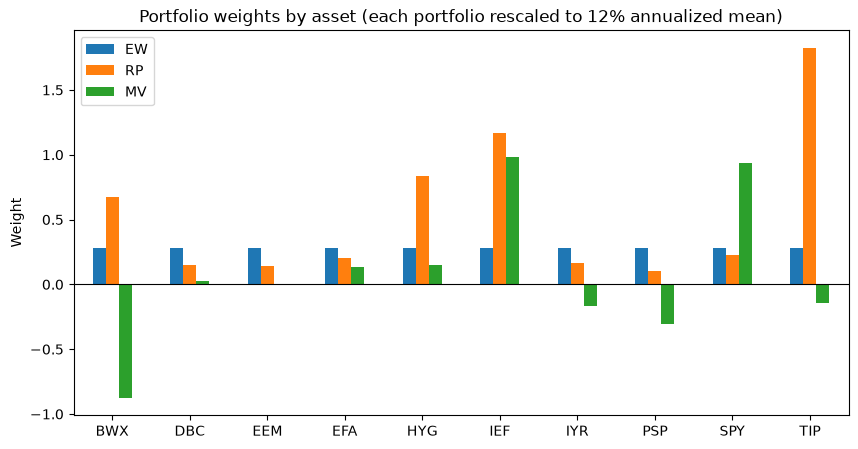

In [19]:
# ── Weights by asset, across the three allocation methods ────────────────────

fig, ax = plt.subplots(figsize=(10, 5))
weights.loc[rets.columns].plot.bar(ax=ax)
ax.axhline(0, color='k', lw=0.8)
ax.set_title('Portfolio weights by asset (each portfolio rescaled to 12% annualized mean)')
ax.set_ylabel('Weight')
plt.xticks(rotation=0)
plt.legend(title=None)
plt.show()

In [22]:
# ── Performance of each allocation over the full sample ───────────────────────

port_rets  = pd.DataFrame({name: rets @ w for name, w in [('EW', w_ew), ('RP', w_rp), ('MV', w_mv)]})
alloc_perf = performance_summary(port_rets)

alloc_perf.style.format({'Mean': '{:.2%}', 'Volatility': '{:.2%}', 'Sharpe': '{:.3f}'}) \
    .background_gradient(subset=['Sharpe'], cmap='RdYlGn')

,Mean,Volatility,Sharpe
EW,12.00%,27.53%,0.436
RP,12.00%,32.61%,0.368
MV,12.00%,8.13%,1.476


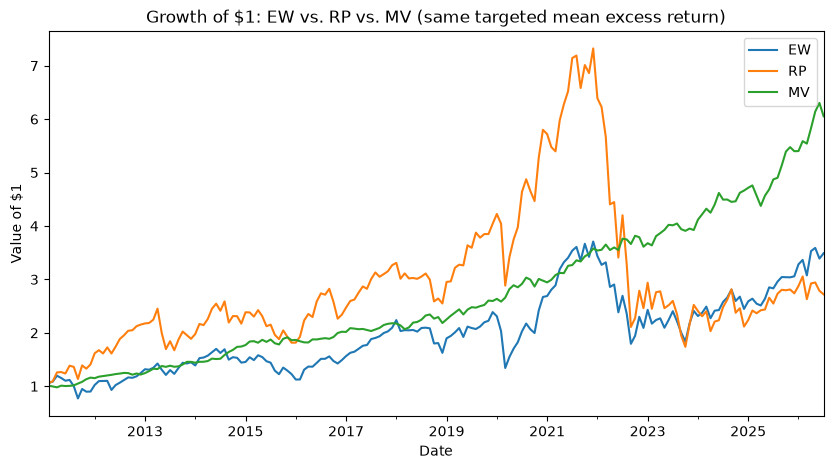

In [21]:
# ── Growth of $1, EW vs. RP vs. MV (all rescaled to the 12% target mean) ─────

fig, ax = plt.subplots()
(1 + port_rets).cumprod().plot(ax=ax)
ax.set_title('Growth of $1: EW vs. RP vs. MV (same targeted mean excess return)')
ax.set_ylabel('Value of $1')
plt.show()

**Takeaways (Allocations)**

* **MV wins by a lot.** Scaled to the same 12% mean, MV gets there with ≈ 8% vol and a 1.48 Sharpe, vs. ≈ 27-33% vol and a Sharpe near 0.4 for EW and RP. This isn't super surprising because the tangency portfolio is optimized for a given target return.
* Scaling a weight vector up or down is leverage and doesn't affect the Sharpe ratio, so MV's Sharpe here is the same as the un-scaled tangency Sharpe from 2.3 (1.476). The real difference between the three methods is the shape of the weights, not the target mean itself.
* **RP actually loses to plain equal-weighting.** It piles into the lowest-vol assets (TIP, IEF) regardless of what they return, so it needs ≈ 5.5x leverage to hit the target and still ends up more volatile and lower-Sharpe than EW.
* MV's net weight is only ≈ 0.74 (leaving room for the risk-free asset), but gross exposure is ≈ 3.7x once you count the long/short pairs (long SPY & IEF, short BWX/IYR/PSP/TIP). This shows that MV is efficient and probably part of why Harvard caps its actual allocations instead of running the raw optimizer.

## Citations

Sonnet 4.6 (Medium) was used in the generation of code, writing, and analysis